In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:

df = pd.read_csv('./data/titanic_clean.csv')
#En el notebook anterior guardamos nuestros datos limpios en el directorio clean/ . Carguemos estos datos a DataFrames. esto actualiza el valor de dr, ya no tendrá el del archivo 1_clean.ipynb

In [3]:
df.sample(4)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
838,1,3,male,32.0,0,0,56.4958,S
541,0,3,female,9.0,4,2,31.2750,S
862,1,1,female,48.0,0,0,25.9292,S
292,0,2,male,36.0,0,0,12.8750,C


In [4]:
df['Survived'].value_counts()

#Esto signfica que en nuestro set de entrenamiento tenemos 549 pasajeros fallecidos y 342 que sobrevieron


Survived
0    549
1    342
Name: count, dtype: int64

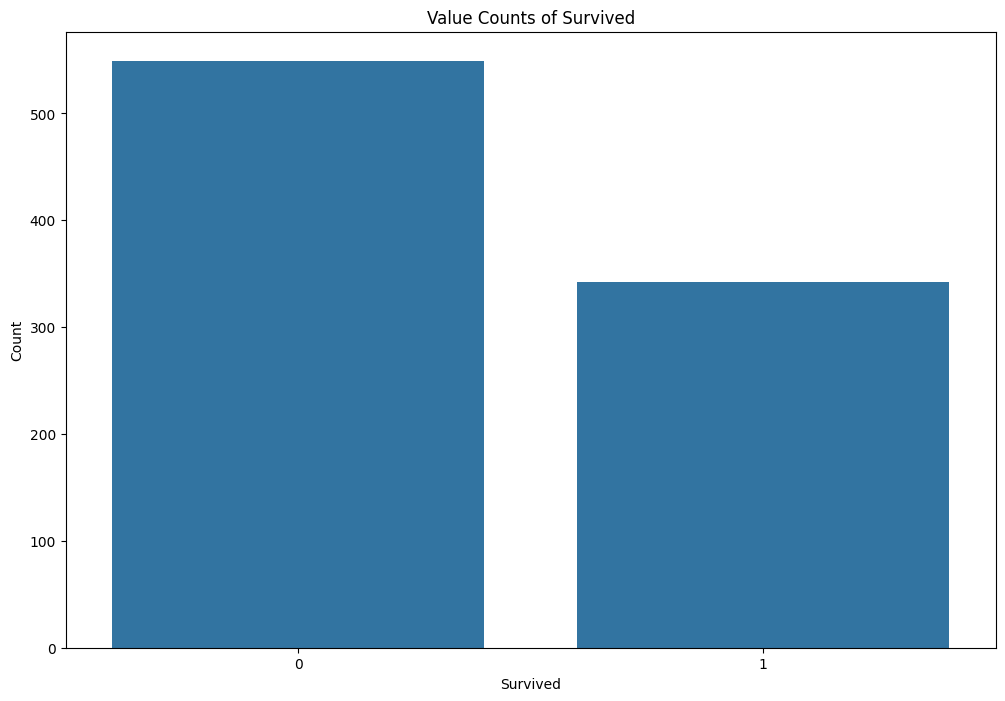

In [5]:
plt.figure(figsize=(12, 8))

sns.barplot(x = df['Survived'].value_counts().index, y = df['Survived'].value_counts())
plt.title('Value Counts of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

#mismos datos pero en gráfica

In [6]:
Tasa_supervivencia = df['Survived'].mean()
print(f"Tasa de supervivencia: {Tasa_supervivencia:.2%}")

Tasa de supervivencia: 38.38%


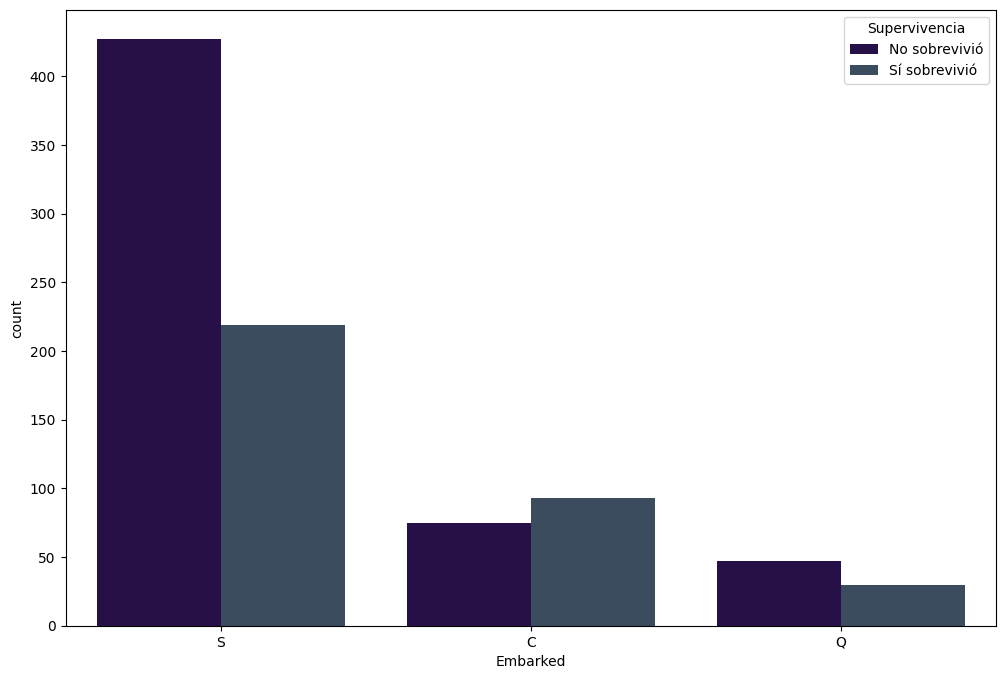

In [7]:
#veamos la tasa de supervivencia por puerto de embarque
plt.figure(figsize = (12, 8))

# colores para cada una de las clases
color = ['#240750', '#344C64']

sns.countplot(df, x = 'Embarked', hue = 'Survived', palette=color) 
plt.legend(title = 'Supervivencia', labels = ['No sobrevivió', 'Sí sobrevivió'])
plt.show()

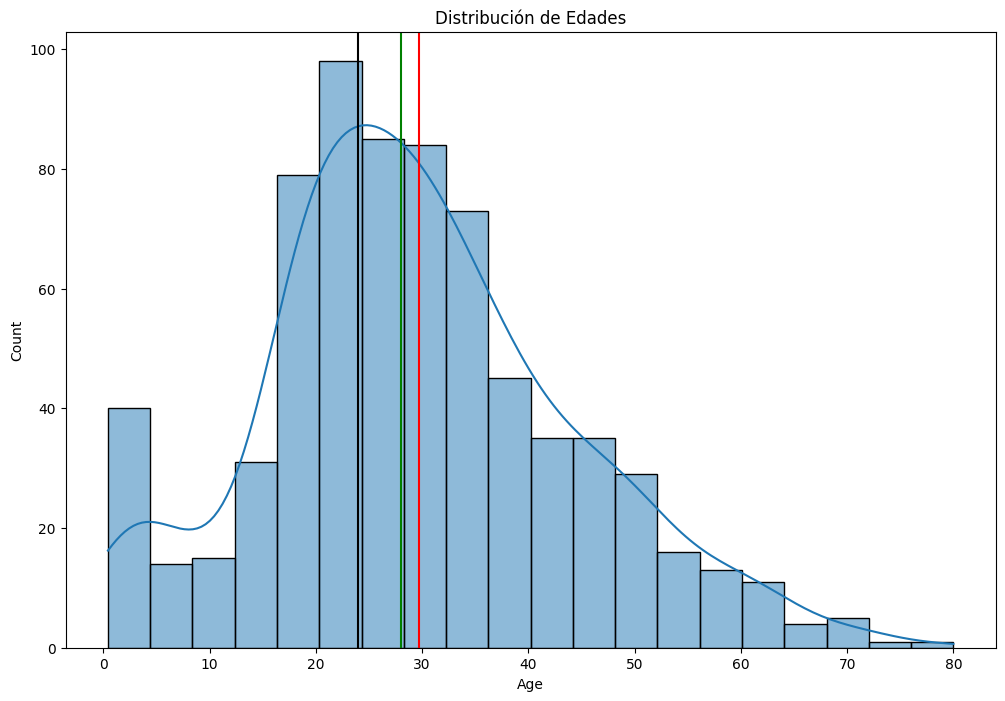

Media: 29.69911764705882
Mediana: 28.0
Moda: 24.0


In [8]:
#distribución de las edades
plt.figure(figsize = (12, 8))

sns.histplot(df, x = 'Age', kde = True)
plt.title('Distribución de Edades')
plt.axvline(df['Age'].mean(), color = 'red')
plt.axvline(df['Age'].median(), color = 'green')
plt.axvline(df['Age'].mode()[0], color = 'black')
plt.show()

# Print the results
print(f"Media: {df['Age'].mean()}")
print(f"Mediana: {df['Age'].median()}")
print(f"Moda: {df['Age'].mode()[0]}")

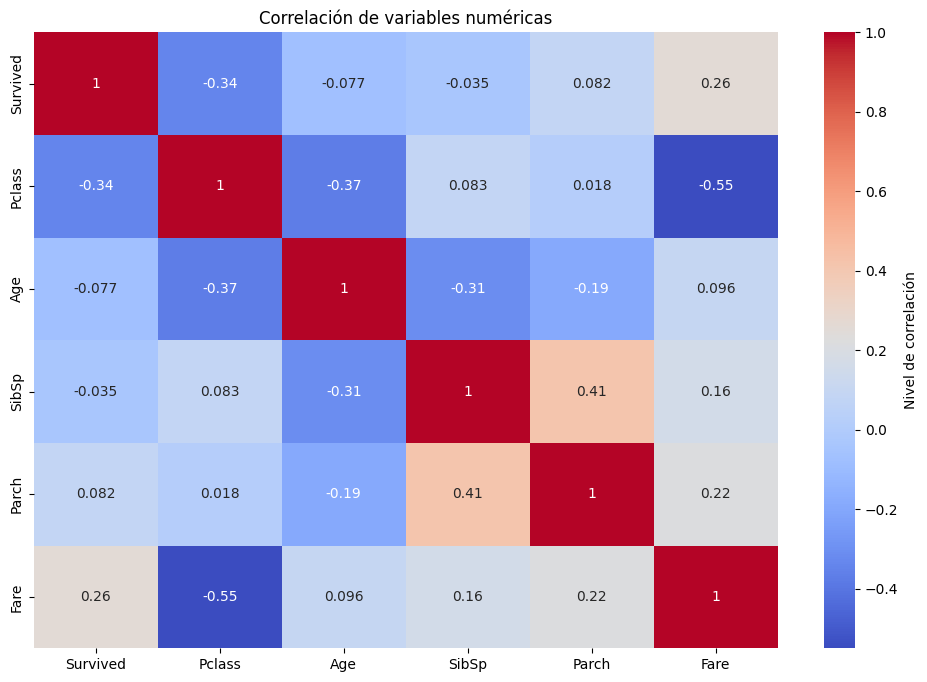

In [9]:
plt.figure(figsize = (12, 8))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(), 
            annot=True, 
            cbar=True,  # Activar la barra de colores
            cmap='coolwarm',  # Cambiar la paleta de colores
            cbar_kws={'label': 'Nivel de correlación'})  # Etiqueta para la barra de colores
plt.title('Correlación de variables numéricas')
plt.show()

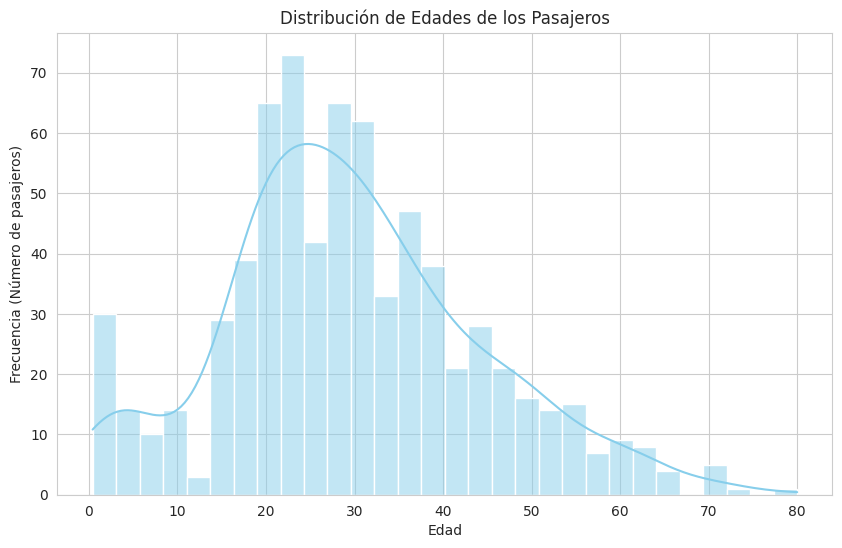

In [10]:
#Crea una gráfica que muestre la distribución de edades de los pasajeros.

import seaborn as sns
import matplotlib.pyplot as plt

# Configurar el estilo y el tamaño
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Crear el histograma con curva de densidad
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='skyblue')

# Personalización
plt.title('Distribución de Edades de los Pasajeros')
plt.xlabel('Edad')
plt.ylabel('Frecuencia (Número de pasajeros)')

plt.show()

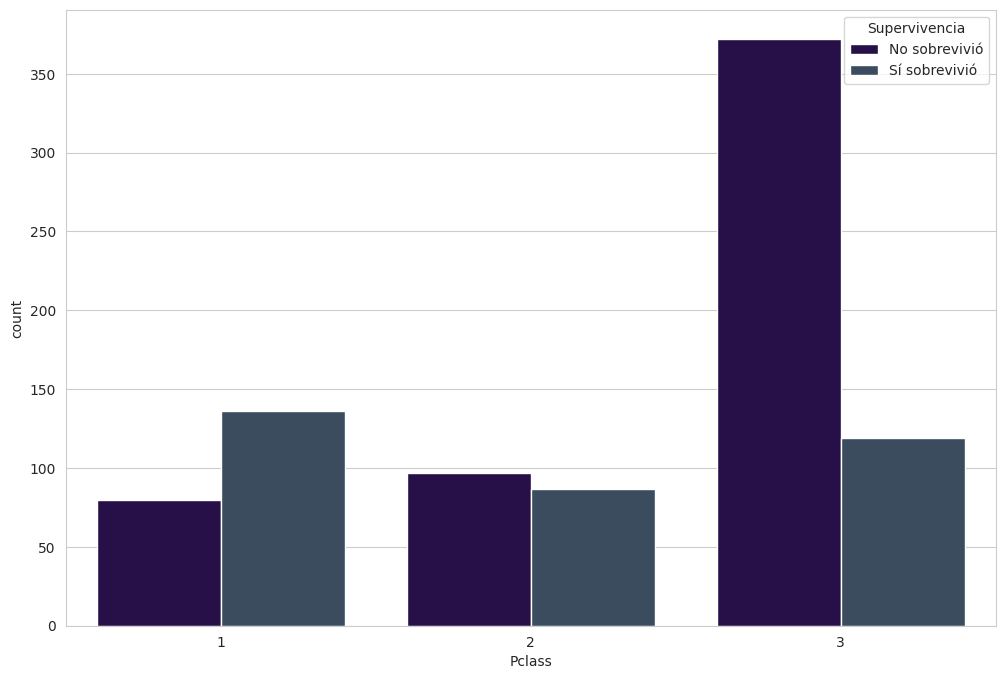

In [11]:
#Crea una gráfica que muestre la cantidad de sobrevivientes por clase de pasajero (Pclass).
plt.figure(figsize = (12, 8))

# colores para cada una de las clases
color = ['#240750', '#344C64']

sns.countplot(df, x = 'Pclass', hue = 'Survived', palette=color) 
plt.legend(title = 'Supervivencia', labels = ['No sobrevivió', 'Sí sobrevivió'])
plt.show()

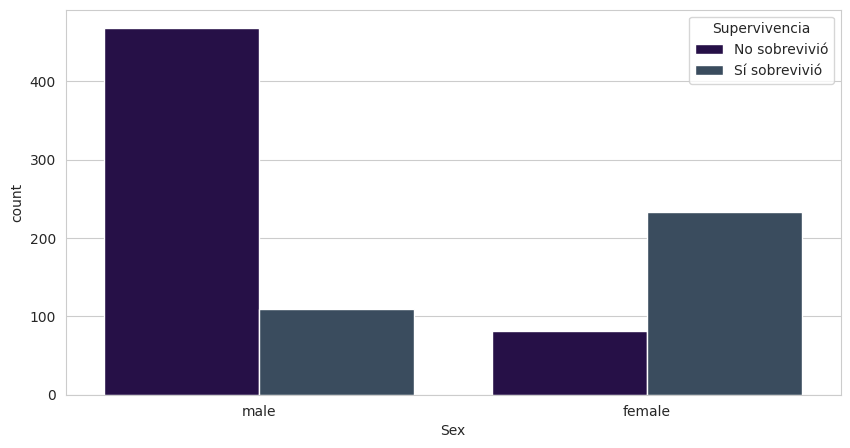

In [12]:
#Crea una gráfica que muestre la cantidad de sobrevivientes por género (Sex).
plt.figure(figsize = (10, 5))

color = ['#240750', '#344C64']

# Personalización
sns.countplot(df, x = 'Sex', hue = 'Survived', palette=color) 
plt.legend(title = 'Supervivencia', labels = ['No sobrevivió', 'Sí sobrevivió'])
plt.show()

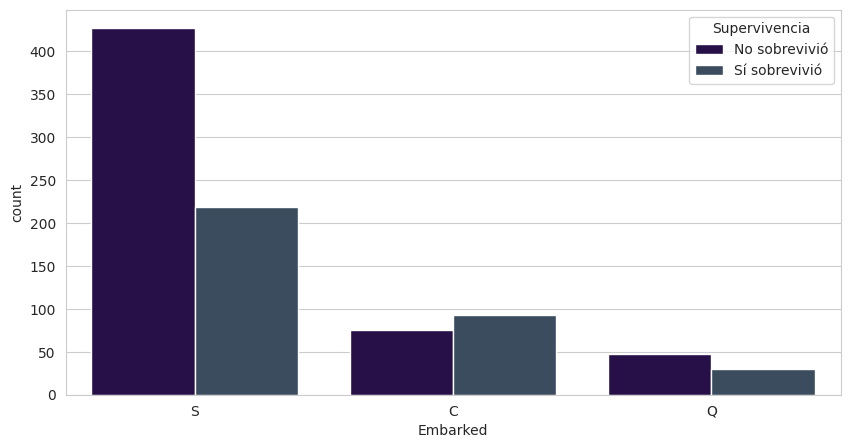

In [13]:
#Crea una gráfica que muestre la cantidad de sobrevivientes por puerto de embarque (Embarked).
plt.figure(figsize = (10, 5))

color = ['#240750', '#344C64']

sns.countplot(df, x= ('Embarked'), hue = 'Survived', palette=color)
plt.legend(title = 'Supervivencia', labels = ['No sobrevivió', 'Sí sobrevivió'])
plt.show()

/tmp/ipykernel_7485/1280159102.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='GrupoEdad', y='Survived', data=tasa_por_edad, palette='viridis')


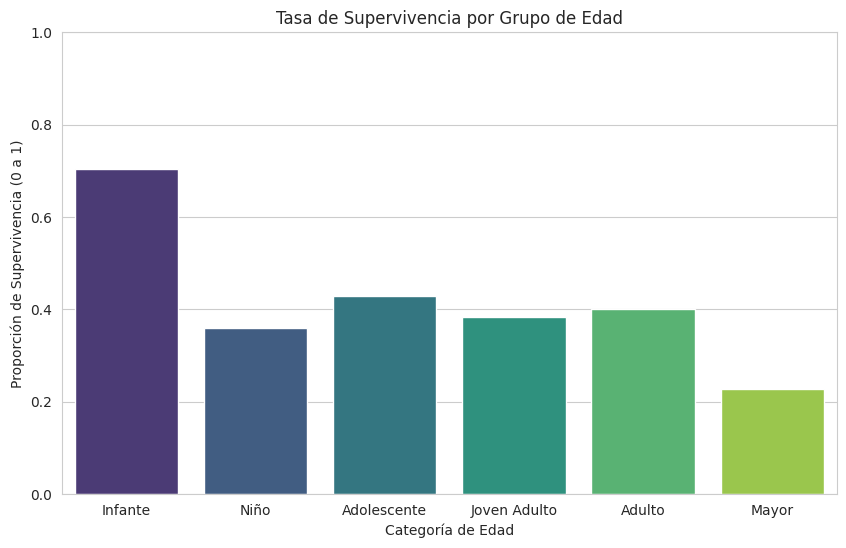

In [14]:
#Agrupa las edades en categorías (Infante, Niño, Adolescente, Joven Adulto, Adulto, Mayor) y crea una gráfica que muestre la tasa de supervivencia por grupo de edad.

# 1. Definir los cortes de edad y las etiquetas
bins = [0, 5, 12, 18, 35, 60, 100]
labels = ['Infante', 'Niño', 'Adolescente', 'Joven Adulto', 'Adulto', 'Mayor']

# 2. Crear la nueva columna 'GrupoEdad'
# Usamos dropna() para que no de error si hay nulos en Age
df['GrupoEdad'] = pd.cut(df['Age'], bins=bins, labels=labels)

# 3. Calcular la tasa de supervivencia por grupo
tasa_por_edad = df.groupby('GrupoEdad')['Survived'].mean().reset_index()

# 4. Crear la gráfica
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.barplot(x='GrupoEdad', y='Survived', data=tasa_por_edad, palette='viridis')

# Personalización
plt.title('Tasa de Supervivencia por Grupo de Edad')
plt.ylabel('Proporción de Supervivencia (0 a 1)')
plt.xlabel('Categoría de Edad')
plt.ylim(0, 1) # La tasa va de 0% a 100%

plt.show()

/tmp/ipykernel_7485/485967141.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette='Set2')


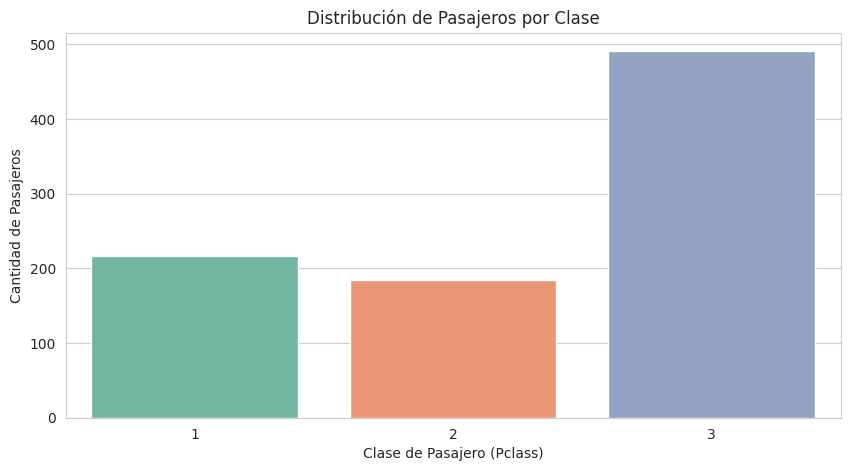

In [15]:
#Crea una gráfica que muestre el conteo de pasajeros en cada clase (Pclass).
sns.set_style("whitegrid")
plt.figure(figsize = (10, 5))

sns.countplot(x='Pclass', data=df, palette='Set2')

#x='Pclass': Le dice a Seaborn que use la columna de las clases para el eje horizontal.
#data=df: Especifica que los datos provienen de tu DataFrame cargado anteriormente.
#palette='Set2': Aplica una combinación de colores predefinida para que cada barra tenga un color distinto y agradable.

plt.title('Distribución de Pasajeros por Clase')
plt.xlabel('Clase de Pasajero (Pclass)')
plt.ylabel('Cantidad de Pasajeros')
plt.show()

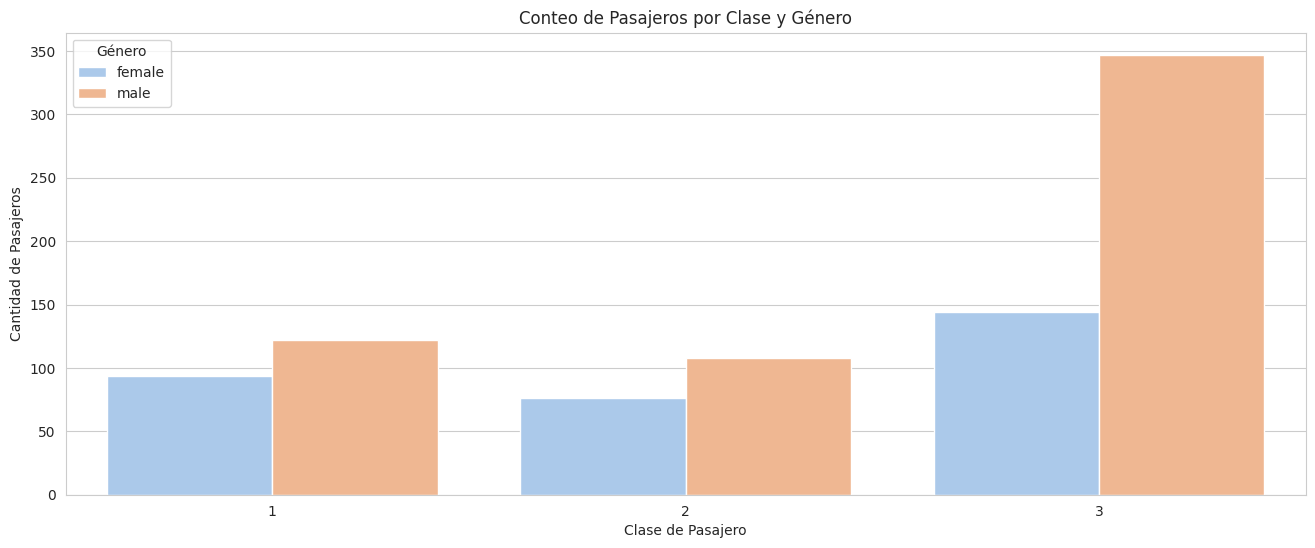

In [16]:
#Crea una gráfica que muestre el conteo de pasajeros en cada clase (Pclass)
sns.set_style("whitegrid")
plt.figure(figsize = (16, 6))

sns.countplot(x='Pclass', hue='Sex', data=df, palette='pastel')

#x='Pclass': Le dice a Seaborn que use la columna de las clases para el eje horizontal.
#data=df: Especifica que los datos provienen de tu DataFrame cargado anteriormente.
#Cuando agregas hue='Sex', Seaborn realiza internamente un proceso de tres pasos sobre tu DataFrame df
#plette='pastel': Aplica una combinación de colores suaves para que cada barra tenga un color distinto y agradable.

plt.title('Conteo de Pasajeros por Clase y Género')
plt.xlabel('Clase de Pasajero')
plt.ylabel('Cantidad de Pasajeros')
plt.legend(title='Género')
plt.show()

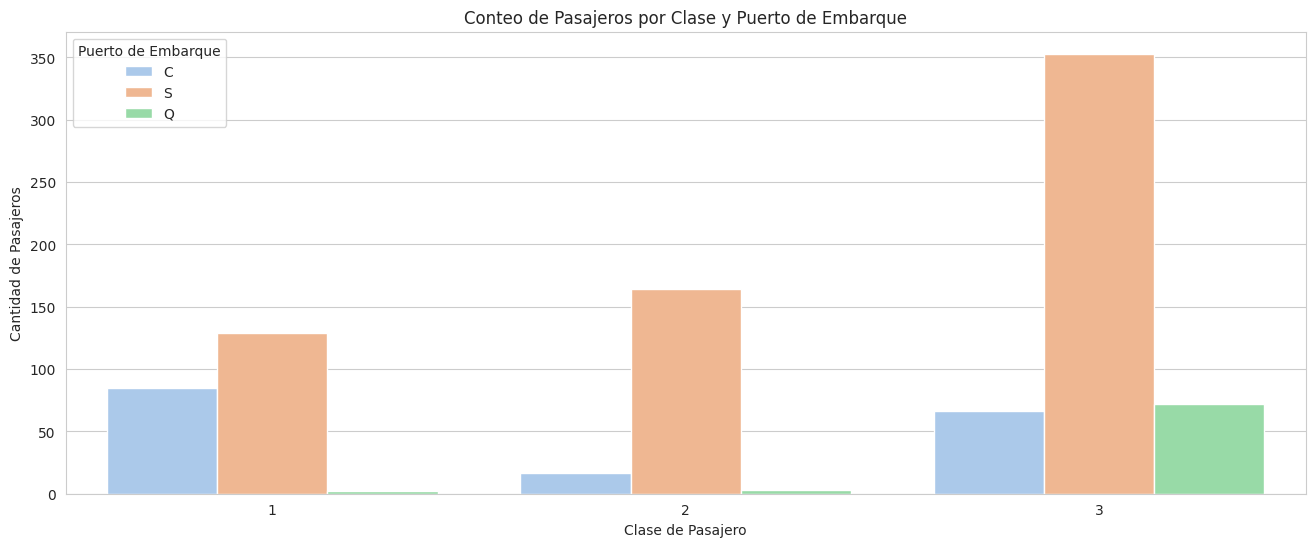

In [17]:
#Crea una gráfica que muestre la distribución de clase de pasajero por puerto de embarque (Embarked).

sns.set_style("whitegrid")
plt.figure(figsize = (16, 6))

sns.countplot(x='Pclass', hue='Embarked', data=df, palette='pastel')


plt.title('Conteo de Pasajeros por Clase y Puerto de Embarque')
plt.xlabel('Clase de Pasajero')
plt.ylabel('Cantidad de Pasajeros')
plt.legend(title='Puerto de Embarque')
plt.show()

/tmp/ipykernel_7485/3976199368.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df, palette='pastel')


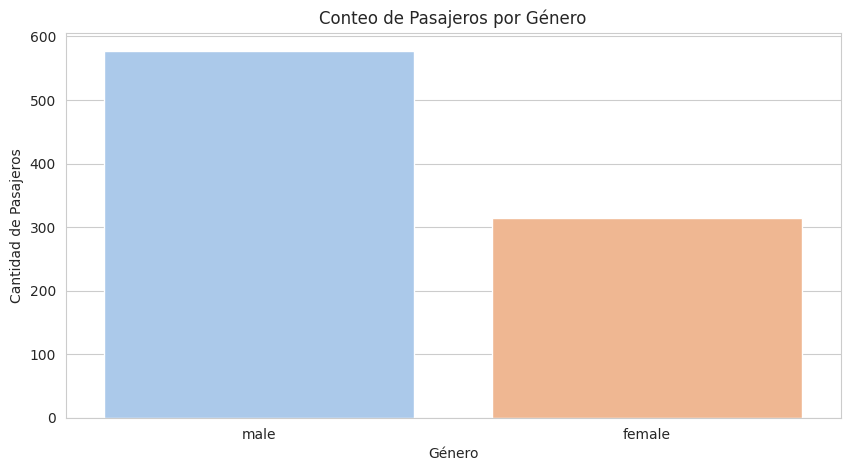

In [18]:
#Crea una gráfica que muestre el conteo de pasajeros por género (Sex).

sns.set_style("whitegrid")
plt.figure(figsize = (10, 5))

sns.countplot(x='Sex', data=df, palette='pastel')


plt.title('Conteo de Pasajeros por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad de Pasajeros')
plt.show()

In [19]:
#Encuentra y muestra los valores máximo y mínimo de la columna de edad.
max_age = df['Age'].max()
min_age = df['Age'].min()
print(f"Edad máxima: {max_age}")
print(f"Edad mínima: {min_age}")

Edad máxima: 80.0
Edad mínima: 0.42


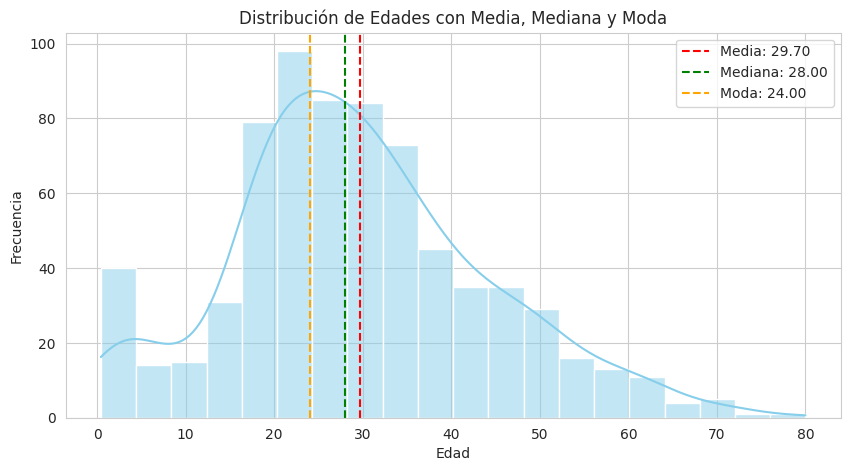

In [20]:
#Crea una gráfica que muestre la distribución de edades, incluyendo líneas verticales que indiquen la media, mediana y moda de las edades.
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))

# Histograma de la distribución de edades
sns.histplot(df['Age'].dropna(), kde=True, color='skyblue')

# Líneas verticales para media, mediana y moda
mean_age = df['Age'].mean()
median_age = df['Age'].median()
mode_age = df['Age'].mode()[0]

plt.axvline(mean_age, color='red', linestyle='--', label=f'Media: {mean_age:.2f}')
plt.axvline(median_age, color='green', linestyle='--', label=f'Mediana: {median_age:.2f}')
plt.axvline(mode_age, color='orange', linestyle='--', label=f'Moda: {mode_age:.2f}')

plt.title('Distribución de Edades con Media, Mediana y Moda')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

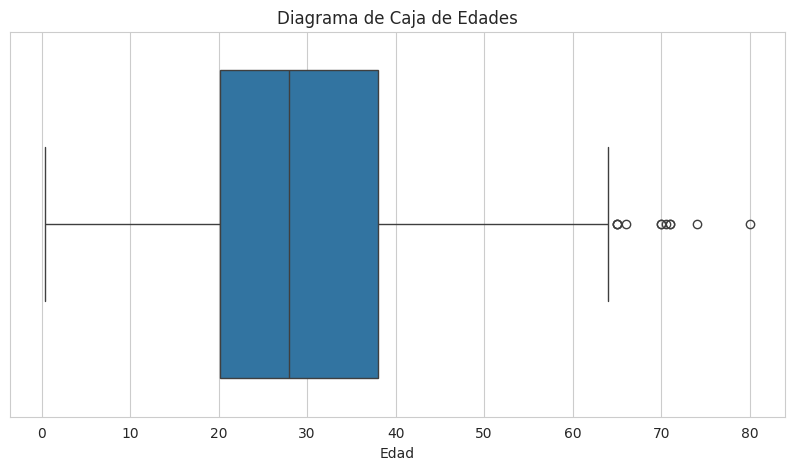

In [21]:
#Crea un diagrama de caja (boxplot) que muestre los outliers en la columna de edad.
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))
sns.boxplot(x='Age', data=df)
plt.title('Diagrama de Caja de Edades')
plt.xlabel('Edad')
plt.show()

In [22]:
#Encuentra y muestra los valores máximo y mínimo de la columna de tarifa (Fare).

max_fare = df['Fare'].max()
min_fare = df['Fare'].min()

print(f"Tarifa máxima: {max_fare}")
print(f"Tarifa mínima: {min_fare}") 


Tarifa máxima: 512.3292
Tarifa mínima: 0.0


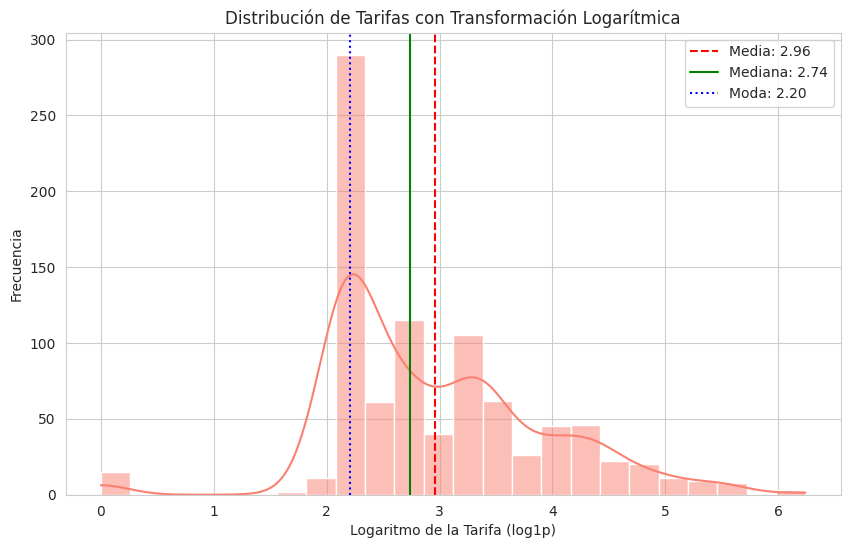

In [23]:
#Crea una gráfica que muestre la distribución de tarifas, incluyendo líneas verticales que indiquen la media, mediana y moda de las tarifas.

#Usamos la estabilidad numérica de log1p para evitar problemas con valores muy pequeños o cero en la columna Fare, que es común en datos de tarifas.

import numpy as np

# 1. Aplicamos la transformación logarítmica log(1 + x)
# Usamos log1p porque es más preciso para valores muy pequeños y maneja el valor 0
df['Fare_log'] = np.log1p(df['Fare'])

# 2. Configuramos la gráfica
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# 3. Histograma de la tarifa transformada
sns.histplot(df['Fare_log'], kde=True, color='salmon')

# 4. Calculamos las nuevas métricas sobre la columna transformada
mean_log = df['Fare_log'].mean()
median_log = df['Fare_log'].median()
mode_log = df['Fare_log'].mode()[0]

# 5. Dibujamos las líneas verticales
plt.axvline(mean_log, color='red', linestyle='--', label=f'Media: {mean_log:.2f}')
plt.axvline(median_log, color='green', linestyle='-', label=f'Mediana: {median_log:.2f}')
plt.axvline(mode_log, color='blue', linestyle=':', label=f'Moda: {mode_log:.2f}')

plt.title('Distribución de Tarifas con Transformación Logarítmica')
plt.xlabel('Logaritmo de la Tarifa (log1p)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

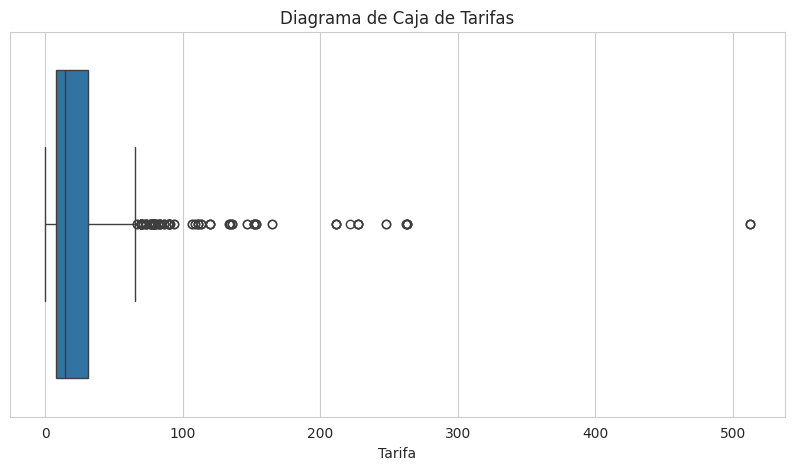

In [24]:
#Crea un diagrama de caja (boxplot) que muestre los outliers en la columna de tarifa (Fare).

sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))
sns.boxplot(x='Fare', data=df)
plt.title('Diagrama de Caja de Tarifas')
plt.xlabel('Tarifa')
plt.show()

In [25]:
#Filtra y muestra los datos de los pasajeros que pagaron 0 en tarifa.
df_zero_fare = df[df['Fare'] == 0]
print(df_zero_fare)

     Survived  Pclass   Sex   Age  SibSp  Parch  Fare Embarked     GrupoEdad  \
179         0       3  male  36.0      0      0   0.0        S        Adulto   
263         0       1  male  40.0      0      0   0.0        S        Adulto   
271         1       3  male  25.0      0      0   0.0        S  Joven Adulto   
277         0       2  male   NaN      0      0   0.0        S           NaN   
302         0       3  male  19.0      0      0   0.0        S  Joven Adulto   
413         0       2  male   NaN      0      0   0.0        S           NaN   
466         0       2  male   NaN      0      0   0.0        S           NaN   
481         0       2  male   NaN      0      0   0.0        S           NaN   
597         0       3  male  49.0      0      0   0.0        S        Adulto   
633         0       1  male   NaN      0      0   0.0        S           NaN   
674         0       2  male   NaN      0      0   0.0        S           NaN   
732         0       2  male   NaN      0

/tmp/ipykernel_7485/1802912678.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SibSp', data=df, palette='viridis')


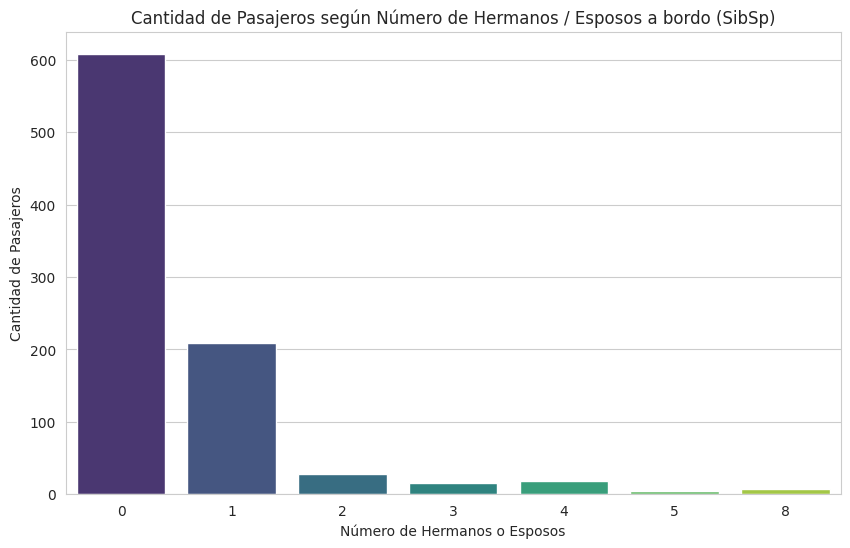

In [26]:
#Crea una gráfica que muestre el conteo de pasajeros por número de hermanos/esposos a bordo (SibSp).

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.countplot(x='SibSp', data=df, palette='viridis')


plt.title('Cantidad de Pasajeros según Número de Hermanos / Esposos a bordo (SibSp)')
plt.xlabel('Número de Hermanos o Esposos')
plt.ylabel('Cantidad de Pasajeros')
plt.show()

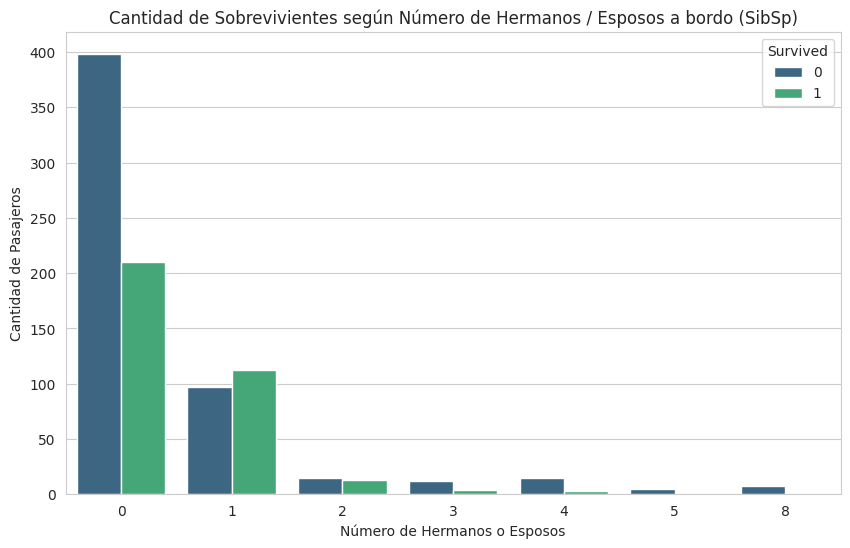

In [27]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.countplot(x='SibSp', hue='Survived', data=df, palette='viridis')


plt.title('Cantidad de Sobrevivientes según Número de Hermanos / Esposos a bordo (SibSp)')
plt.xlabel('Número de Hermanos o Esposos')
plt.ylabel('Cantidad de Pasajeros')
plt.show()

In [28]:
# 1. Agrupamos por 'SibSp' y calculamos la media de 'Survived'


# Multiplicamos por 100 para convertir la proporción en porcentaje
supervivencia_sibsp = df.groupby('SibSp')['Survived'].mean() * 100

# 2. Convertimos a DataFrame para que sea más fácil de leer y graficar
supervivencia_sibsp = supervivencia_sibsp.reset_index()

# 3. Renombramos las columnas para que sean claras
supervivencia_sibsp.columns = ['Hermanos_Esposos', 'Porcentaje_Supervivencia']


print(supervivencia_sibsp)



   Hermanos_Esposos  Porcentaje_Supervivencia
0                 0                 34.539474
1                 1                 53.588517
2                 2                 46.428571
3                 3                 25.000000
4                 4                 16.666667
5                 5                  0.000000
6                 8                  0.000000


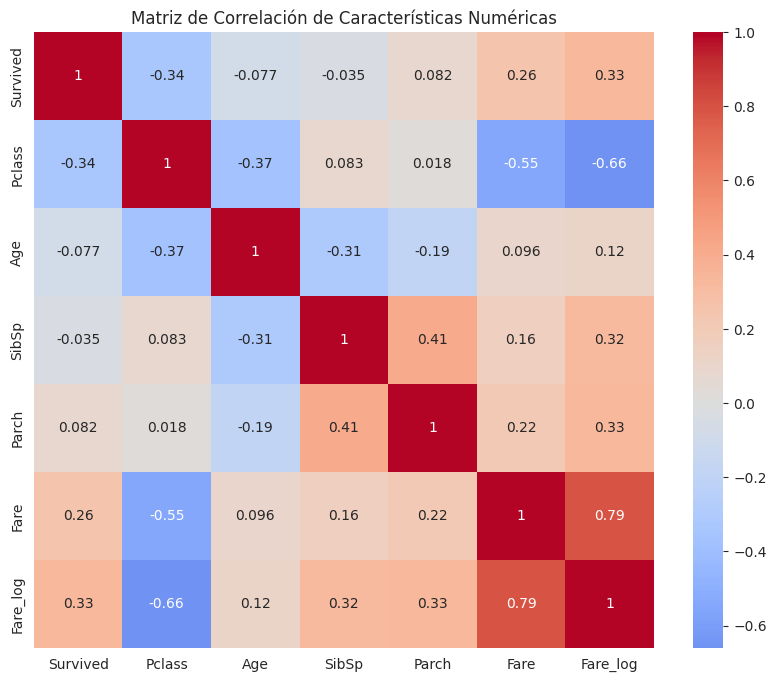

In [29]:
#Crea un mapa de calor (heatmap) que muestre la matriz de correlación de las características numéricas en el dataset.
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación de Características Numéricas')
plt.show()